In [1]:
# Cell 1: Fix Kaggle working directory issue BEFORE any imports
import os
from pathlib import Path

# Force working directory to exist and set it
os.makedirs("/kaggle/working", exist_ok=True)
os.chdir("/kaggle/working")

print("CWD:", os.getcwd())

CWD: /kaggle/working


In [2]:
# Cell 2: Install ultralytics carefully (avoid torch version conflicts)
#!pip install -q ultralytics==8.2.0
#!pip install -q "torch>=2.0.0" "torchvision>=0.15.0" --upgrade

!pip uninstall torch torchvision torchaudio ultralytics -y
!pip install torch torchvision ultralytics
# Restart kernel after this cell if you get import errors!
print("Installation done. If this is first run, go to Run > Restart & Run All")

Found existing installation: torch 2.10.0+cu128
Uninstalling torch-2.10.0+cu128:
  Successfully uninstalled torch-2.10.0+cu128
Found existing installation: torchvision 0.25.0+cu128
Uninstalling torchvision-0.25.0+cu128:
  Successfully uninstalled torchvision-0.25.0+cu128
Found existing installation: torchaudio 2.10.0+cu128
Uninstalling torchaudio-2.10.0+cu128:
  Successfully uninstalled torchaudio-2.10.0+cu128
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 530.7/530.7 MB 3.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 366.1/366.1 MB 2.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.9/169.9 MB 10.8 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.5/196.5 MB 9.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 MB 31.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 MB 4.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [3]:
import torch
print(torch.cuda.is_available())

True


In [4]:
# Cell 3: Safe imports after kernel restart
import os
os.makedirs("/kaggle/working", exist_ok=True)
os.chdir("/kaggle/working")

import sys
import shutil
import random
import numpy as np
from pathlib import Path

# Test torch first
import torch
import torchvision
print(f"PyTorch     : {torch.__version__}")
print(f"Torchvision : {torchvision.__version__}")
print(f"CUDA        : {torch.cuda.is_available()}")

# Now safe to import ultralytics
from ultralytics import YOLO
print("Ultralytics : OK")

WORK_DIR = Path("/kaggle/working")
print("Working dir :", WORK_DIR)

PyTorch     : 2.11.0+cu130
Torchvision : 0.26.0+cu130
CUDA        : True
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics : OK
Working dir : /kaggle/working


In [5]:
# Cell 4: Download DOTAv1 pre-tiled dataset from Ultralytics
import os
from pathlib import Path

WORK_DIR = Path("/kaggle/working")
DATASET_DIR = WORK_DIR / "datasets"

ZIP_PATH = WORK_DIR / "DOTAv1.zip"
EXTRACT_PATH = DATASET_DIR

if not (DATASET_DIR / "DOTAv1").exists():
    print("Downloading DOTAv1 (~2GB)...")
    
    os.system(
        f"wget -q --show-progress "
        f"-O {ZIP_PATH} "
        "https://github.com/ultralytics/assets/releases/download/v0.0.0/DOTAv1.zip"
    )

    print("Extracting...")
    os.makedirs(EXTRACT_PATH, exist_ok=True)
    os.system(f"unzip -q {ZIP_PATH} -d {EXTRACT_PATH}")
    os.system(f"rm {ZIP_PATH}")

    print("Done!")
else:
    print("Dataset already present, skipping.")

# ✅ Correct dataset path
DATASET_DIR = DATASET_DIR / "DOTAv1"

# Verify (FIXED)
for split in ["train", "val"]:
    img_path = DATASET_DIR / "images" / split
    lbl_path = DATASET_DIR / "labels" / split

    imgs = list(img_path.glob("*.*")) if img_path.exists() else []
    lbls = list(lbl_path.glob("*.txt")) if lbl_path.exists() else []

    print(f"{split}: {len(imgs)} images | {len(lbls)} labels")


     0K .......... .......... .......... .......... ..........  0% 18.7M 1m42s
    50K .......... .......... .......... .......... ..........  0% 71.6M 64s
   100K .......... .......... .......... .......... ..........  0% 36.1M 60s
   150K .......... .......... .......... .......... ..........  0%  138M 49s
   200K .......... .......... .......... .......... ..........  0%  197M 41s
   250K .......... .......... .......... .......... ..........  0% 39.6M 42s
   300K .......... .......... .......... .......... ..........  0%  227M 37s
   350K .......... .......... .......... .......... ..........  0%  189M 34s
   400K .......... .......... .......... .......... ..........  0%  105M 32s
   450K .......... .......... .......... .......... ..........  0%  196M 30s
   500K .......... .......... .......... .......... ..........  0%  255M 28s
   550K .......... .......... .......... .......... ..........  0% 99.5M 27s
   600K .......... .......... .......... .......... ..........  0%  123M 

Extracting...
Done!
train: 1411 images | 1411 labels
val: 458 images | 458 labels


In [6]:
import os

for root, dirs, files in os.walk("/kaggle/working/datasets"):
    print(root)

/kaggle/working/datasets
/kaggle/working/datasets/DOTAv1
/kaggle/working/datasets/DOTAv1/labels
/kaggle/working/datasets/DOTAv1/labels/val
/kaggle/working/datasets/DOTAv1/labels/train_original
/kaggle/working/datasets/DOTAv1/labels/train
/kaggle/working/datasets/DOTAv1/labels/val_original
/kaggle/working/datasets/DOTAv1/images
/kaggle/working/datasets/DOTAv1/images/val
/kaggle/working/datasets/DOTAv1/images/test
/kaggle/working/datasets/DOTAv1/images/train


In [7]:
# Cell 5: Verify bridge class exists in downloaded labels
DOTA_CLASSES = [
    "plane", "ship", "storage-tank", "baseball-diamond",
    "tennis-court", "basketball-court", "ground-track-field",
    "harbor", "bridge", "large-vehicle", "small-vehicle",
    "helicopter", "roundabout", "soccer-ball-field", "swimming-pool"
]
BRIDGE_ID = DOTA_CLASSES.index("bridge")  # = 8

def count_class(label_dir, class_id):
    total, files = 0, 0
    for f in Path(label_dir).glob("*.txt"):
        found = False
        for line in open(f):
            if line.strip().startswith(str(class_id) + " "):
                total += 1
                found = True
        if found:
            files += 1
    return total, files

for split in ["train", "val"]:
    n, f = count_class(DATASET_DIR / f"labels/{split}", BRIDGE_ID)
    print(f"{split}: {n} bridge instances across {f} image tiles")

train: 2047 bridge instances across 210 image tiles
val: 464 bridge instances across 75 image tiles


In [8]:
# Cell 6: Write YAML config
import yaml
from pathlib import Path

WORK_DIR    = Path("/kaggle/working")
DATASET_DIR = WORK_DIR / "datasets" / "DOTAv1"

DOTA_CLASSES = [
    "plane", "ship", "storage-tank", "baseball-diamond",
    "tennis-court", "basketball-court", "ground-track-field",
    "harbor", "bridge", "large-vehicle", "small-vehicle",
    "helicopter", "roundabout", "soccer-ball-field", "swimming-pool"
]

dataset_yaml = {
    "path": str(DATASET_DIR),
    "train": "images/train",
    "val":   "images/val",
    "nc":    15,
    "names": DOTA_CLASSES
}

yaml_path = WORK_DIR / "dota_bridge.yaml"
with open(yaml_path, "w") as f:
    yaml.dump(dataset_yaml, f, default_flow_style=False)

print("YAML written to:", yaml_path)
print(open(yaml_path).read())

YAML written to: /kaggle/working/dota_bridge.yaml
names:
- plane
- ship
- storage-tank
- baseball-diamond
- tennis-court
- basketball-court
- ground-track-field
- harbor
- bridge
- large-vehicle
- small-vehicle
- helicopter
- roundabout
- soccer-ball-field
- swimming-pool
nc: 15
path: /kaggle/working/datasets/DOTAv1
train: images/train
val: images/val



Found 210 tiles with bridges. Showing first 4...



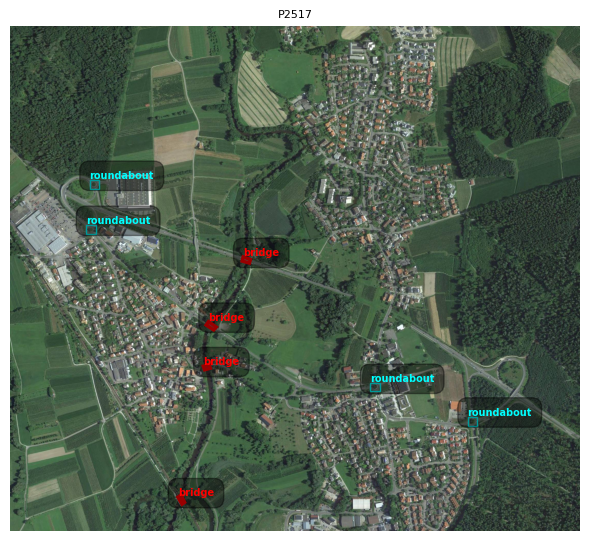

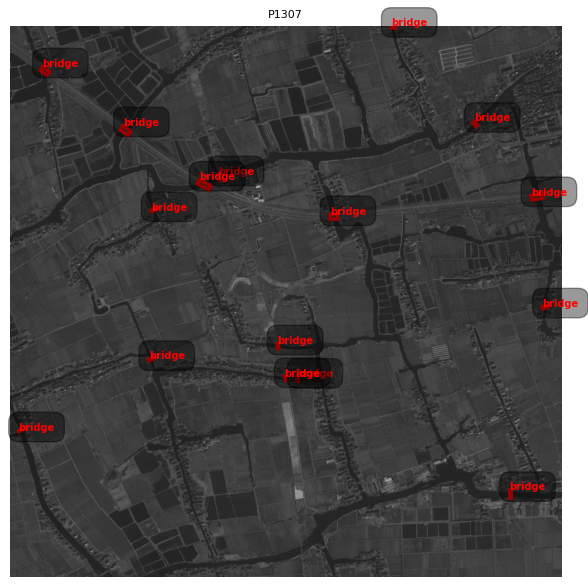

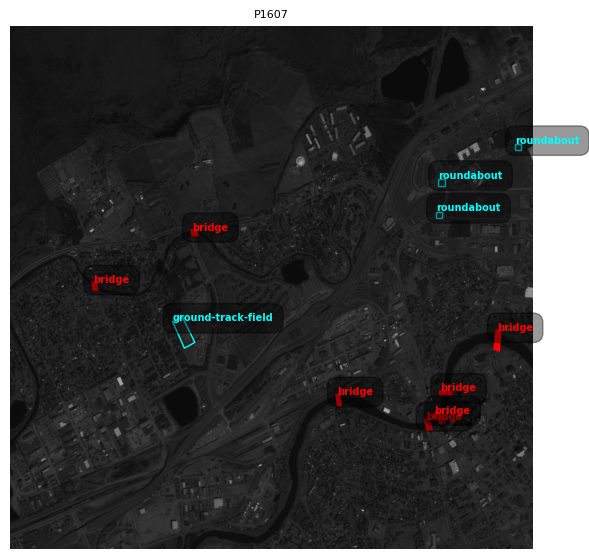

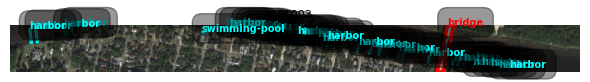

In [9]:
# Cell 7: Visualize bridge annotations before training
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

DATASET_DIR = Path("/kaggle/working/datasets/DOTAv1")
BRIDGE_ID   = 8

DOTA_CLASSES = [
    "plane", "ship", "storage-tank", "baseball-diamond",
    "tennis-court", "basketball-court", "ground-track-field",
    "harbor", "bridge", "large-vehicle", "small-vehicle",
    "helicopter", "roundabout", "soccer-ball-field", "swimming-pool"
]

def plot_obb_tile(img_path, lbl_path, bridge_only=False):
    img = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
    H, W = img.shape[:2]

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(img)

    if lbl_path.exists():
        with open(lbl_path) as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) < 9:
                    continue
                cls_id = int(parts[0])
                if bridge_only and cls_id != BRIDGE_ID:
                    continue
                pts = np.array(list(map(float, parts[1:9]))).reshape(4, 2)
                pts_px = pts * np.array([W, H])
                color = "red" if cls_id == BRIDGE_ID else "cyan"
                lw    = 2.5 if cls_id == BRIDGE_ID else 1.0
                poly  = plt.Polygon(pts_px, fill=False, edgecolor=color, linewidth=lw)
                ax.add_patch(poly)
                label = DOTA_CLASSES[cls_id]
                ax.text(pts_px[0,0], pts_px[0,1] - 4, label,
                        color=color, fontsize=7, fontweight="bold",
                        bbox=dict(fc="black", alpha=0.4, pad=1, boxstyle="round"))

    ax.axis("off")
    ax.set_title(img_path.stem, fontsize=8)
    plt.tight_layout()
    plt.show()

# Find tiles that have bridge annotations
bridge_tiles = []
for lbl in (DATASET_DIR / "labels/train").glob("*.txt"):
    for line in open(lbl):
        if line.startswith(str(BRIDGE_ID) + " "):
            bridge_tiles.append(lbl)
            break

print(f"Found {len(bridge_tiles)} tiles with bridges. Showing first 4...\n")

for lbl_path in bridge_tiles[:4]:
    img_path = DATASET_DIR / "images/train" / (lbl_path.stem + ".png")
    if not img_path.exists():
        img_path = img_path.with_suffix(".jpg")
    if img_path.exists():
        plot_obb_tile(img_path, lbl_path, bridge_only=False)

In [10]:
# Improved training — fix the low bridge AP
from ultralytics import YOLO
from pathlib import Path

WORK_DIR  = Path("/kaggle/working")
yaml_path = WORK_DIR / "dota_bridge.yaml"

# Upgrade to small model — much better than nano for thin objects
model = YOLO("yolov8s-obb.pt")

results = model.train(
    data      = str(yaml_path),
    epochs    = 100,           # was 50 — give it more time
    imgsz     = 1024,
    batch     = 8,
    device    = 0,
    project   = str(WORK_DIR / "runs"),
    name      = "bridge_obb_v2",
    patience  = 20,            # was 10 — stopped too early before

    # Stronger augmentation for thin oriented objects
    degrees   = 180.0,
    flipud    = 0.5,
    fliplr    = 0.5,
    mosaic    = 1.0,
    scale     = 0.6,
    translate = 0.1,
    copy_paste= 0.3,           # copies bridge instances into other tiles

    # Longer warmup
    warmup_epochs = 5,

    exist_ok  = True,
    verbose   = True
)

Ultralytics 8.4.37 🚀 Python-3.12.12 torch-2.11.0+cu130 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.3, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/dota_bridge.yaml, degrees=180.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.5, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1024, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s-obb.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=bridge_obb_v2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True,

In [13]:
# Cell 9: Evaluate on validation set
from ultralytics import YOLO
from pathlib import Path

WORK_DIR     = Path("/kaggle/working")
best_weights = WORK_DIR / "runs/bridge_obb_v2/weights/best.pt"

model_eval = YOLO(str(best_weights))
metrics    = model_eval.val(
    data   = str(WORK_DIR / "dota_bridge.yaml"),
    imgsz  = 1024,
    device = 0,
    split  = "val"
)

print("\n====== Validation Results ======")
print(f"mAP@50      : {metrics.box.map50:.4f}")
print(f"mAP@50-95   : {metrics.box.map:.4f}")
print(f"Precision   : {metrics.box.mp:.4f}")
print(f"Recall      : {metrics.box.mr:.4f}")

# Per-class — find bridge row
if hasattr(metrics.box, "ap_class_index"):
    for i, cid in enumerate(metrics.box.ap_class_index):
        if cid == 8:  # bridge
            print(f"\nBridge AP@50 : {metrics.box.ap50[i]:.4f}")
            print(f"Bridge AP    : {metrics.box.ap[i]:.4f}")

Ultralytics 8.4.37 🚀 Python-3.12.12 torch-2.11.0+cu130 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8s-obb summary (fused): 82 layers, 11,417,376 parameters, 0 gradients, 29.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3569.3±649.6 MB/s, size: 1169.8 KB)
val: Scanning /kaggle/working/datasets/DOTAv1/labels/val.cache... 458 images, 2 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 458/458 213.4Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 29/29 1.1it/s 26.2s0.5ss
                   all        458      28853      0.788      0.529      0.549      0.371
                 plane         70       2531      0.929      0.725      0.733      0.574
                  ship        108       8960      0.849       0.54       0.55      0.246
          storage-tank         55       2888      0.783      0.334      0.347      0.184
      baseball-diamond         53        214      0.797      0.668       0.71      0.511
          tennis-co

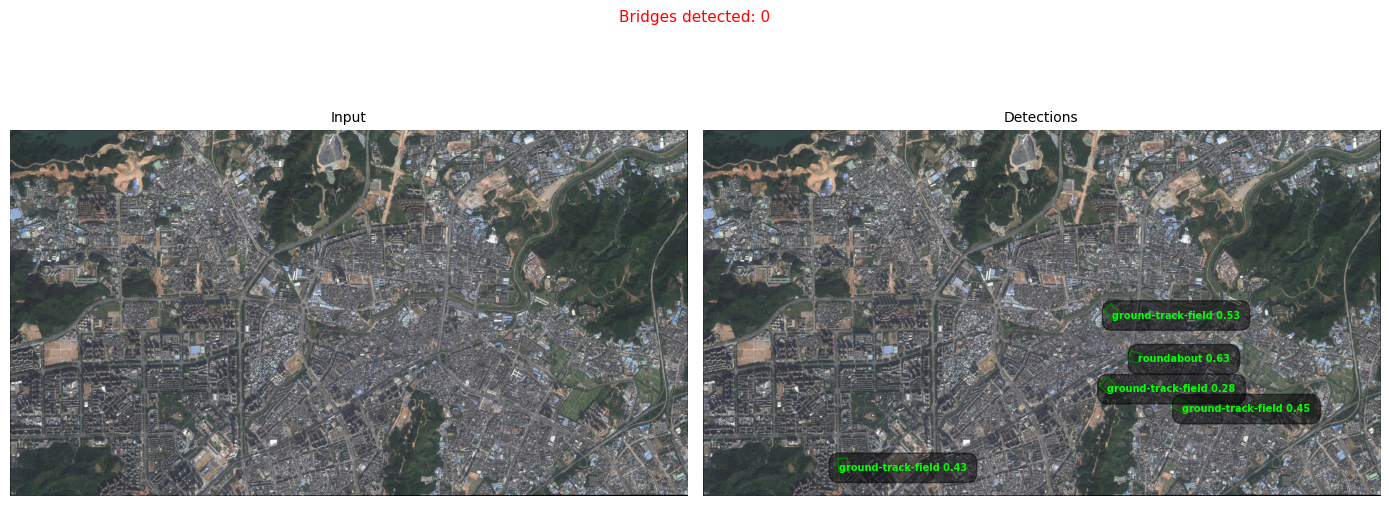

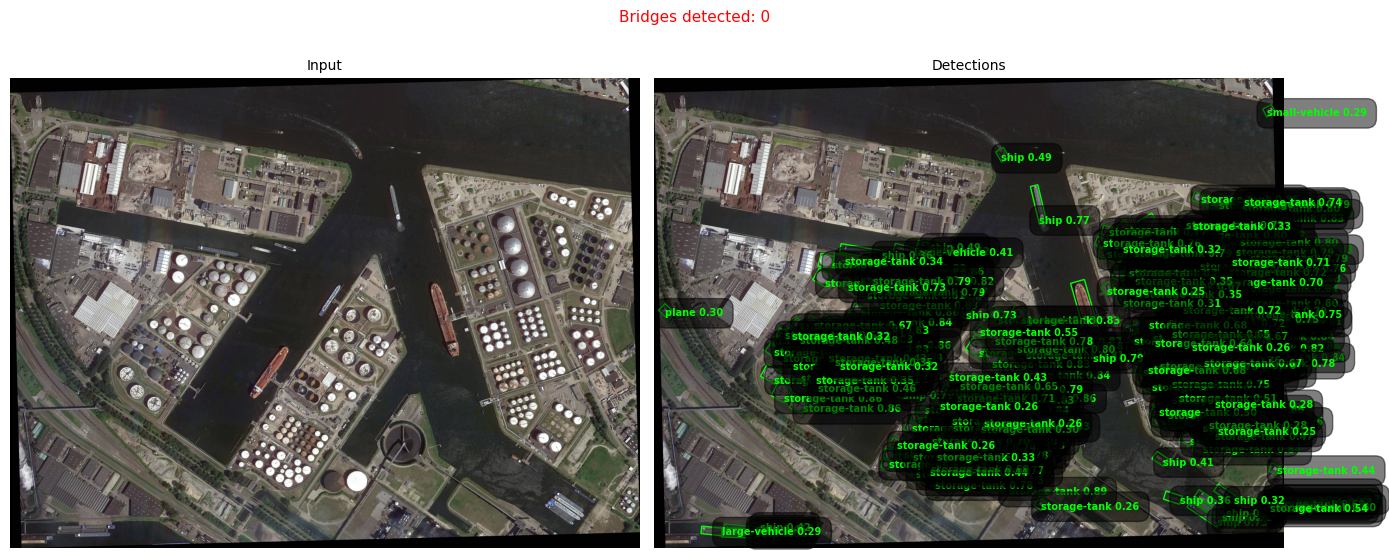

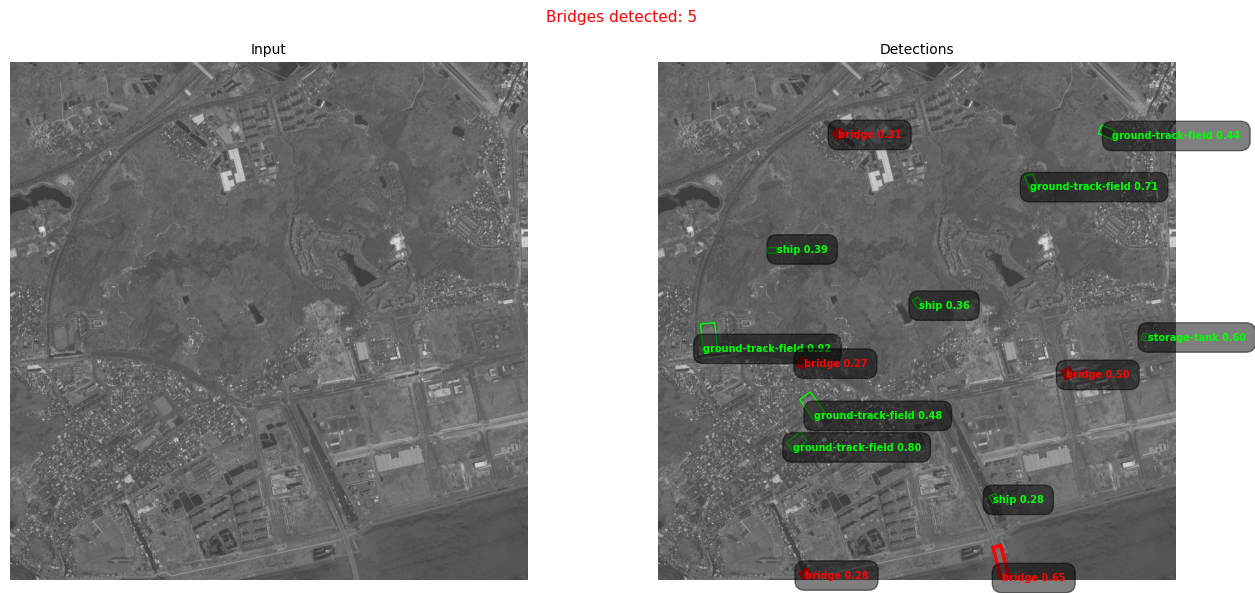

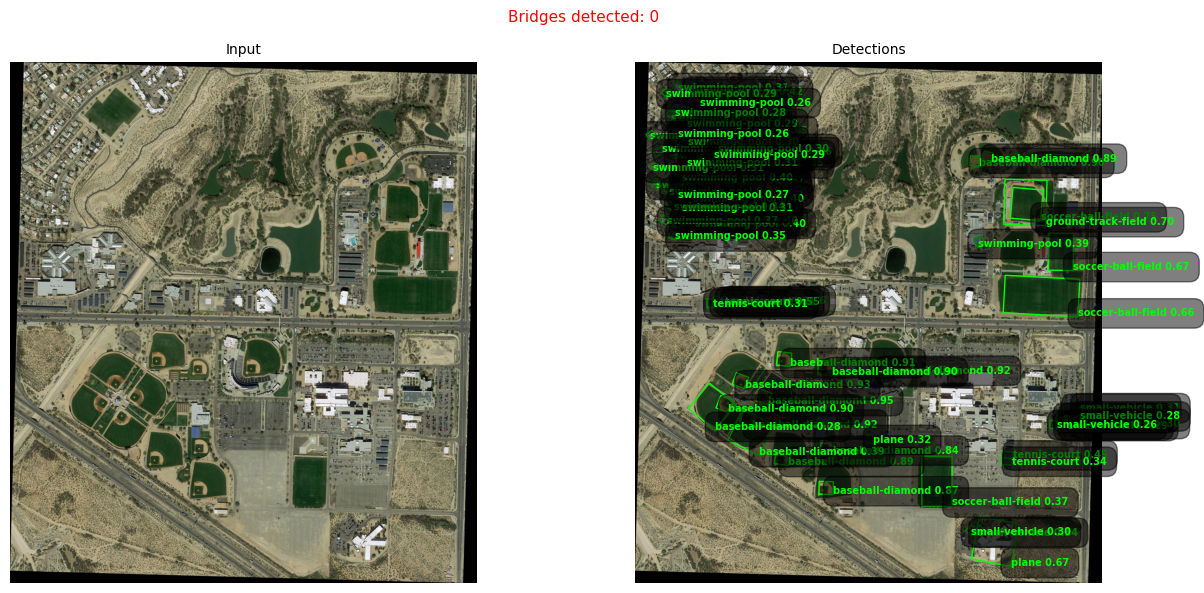

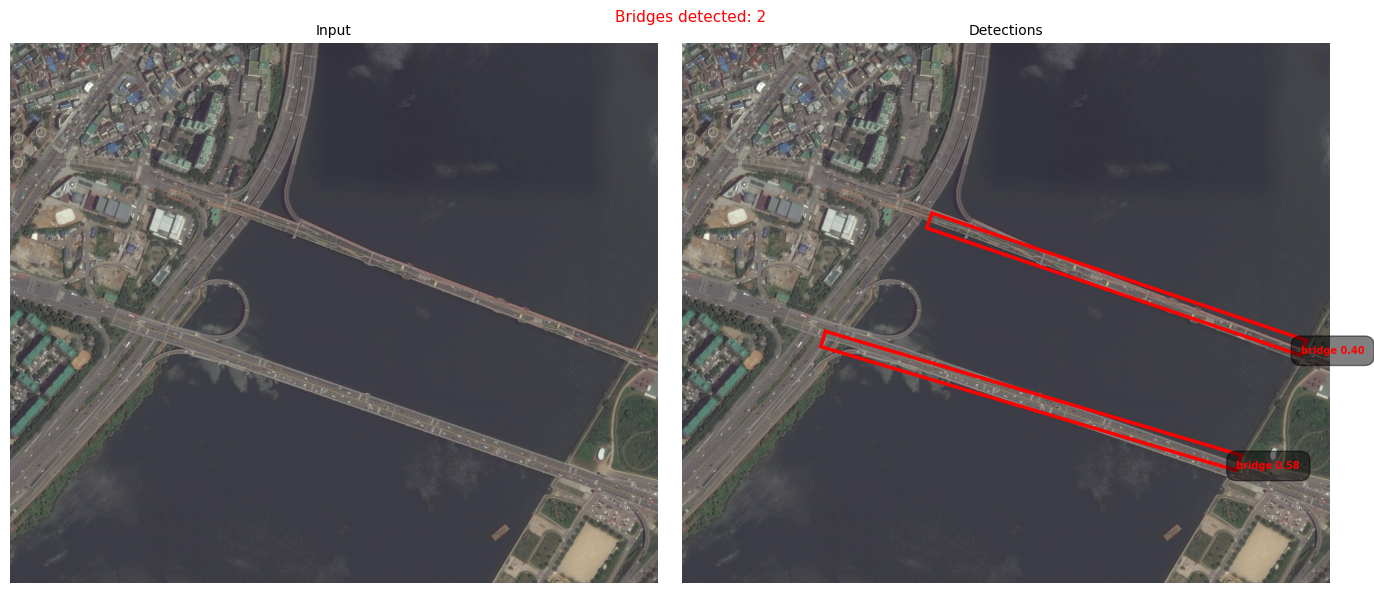

In [15]:
# Cell 10: Run inference on val tiles and visualize bridge detections
import cv2, random
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO
from pathlib import Path

WORK_DIR     = Path("/kaggle/working")
DATASET_DIR  = WORK_DIR / "datasets/DOTAv1"
best_weights = WORK_DIR / "runs/bridge_obb_v2/weights/best.pt"

DOTA_CLASSES = [
    "plane", "ship", "storage-tank", "baseball-diamond",
    "tennis-court", "basketball-court", "ground-track-field",
    "harbor", "bridge", "large-vehicle", "small-vehicle",
    "helicopter", "roundabout", "soccer-ball-field", "swimming-pool"
]

model_infer = YOLO(str(best_weights))

def visualize_prediction(img_path, conf=0.25):
    result = model_infer.predict(
        source=str(img_path), conf=conf, iou=0.5,
        device=0, verbose=False
    )[0]

    img = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    axes[0].imshow(img);  axes[0].set_title("Input", fontsize=10);  axes[0].axis("off")
    axes[1].imshow(img);  axes[1].set_title("Detections", fontsize=10); axes[1].axis("off")

    n_bridges = 0
    if result.obb is not None and len(result.obb):
        for obb in result.obb:
            cls_id     = int(obb.cls.item())
            conf_score = obb.conf.item()
            name       = DOTA_CLASSES[cls_id]
            color      = "red" if name == "bridge" else "lime"
            lw         = 2.5  if name == "bridge" else 1.0
            pts        = obb.xyxyxyxy.cpu().numpy().reshape(4, 2)
            poly       = plt.Polygon(pts, fill=False, edgecolor=color, linewidth=lw)
            axes[1].add_patch(poly)
            axes[1].text(pts[0,0], pts[0,1] - 5,
                         f"{name} {conf_score:.2f}",
                         color=color, fontsize=7, fontweight="bold",
                         bbox=dict(fc="black", alpha=0.5, pad=1, boxstyle="round"))
            if name == "bridge":
                n_bridges += 1

    fig.suptitle(f"Bridges detected: {n_bridges}", fontsize=11, color="red")
    plt.tight_layout()
    plt.show()

# Get bridge-containing val tiles and show 5
val_bridge_tiles = []
for lbl in (DATASET_DIR / "labels/val").glob("*.txt"):
    for line in open(lbl):
        if line.startswith("8 "):
            val_bridge_tiles.append(lbl)
            break

random.shuffle(val_bridge_tiles)
for lbl in val_bridge_tiles[:5]:
    img = DATASET_DIR / "images/val" / (lbl.stem + ".png")
    if not img.exists():
        img = img.with_suffix(".jpg")
    if img.exists():
        visualize_prediction(img)

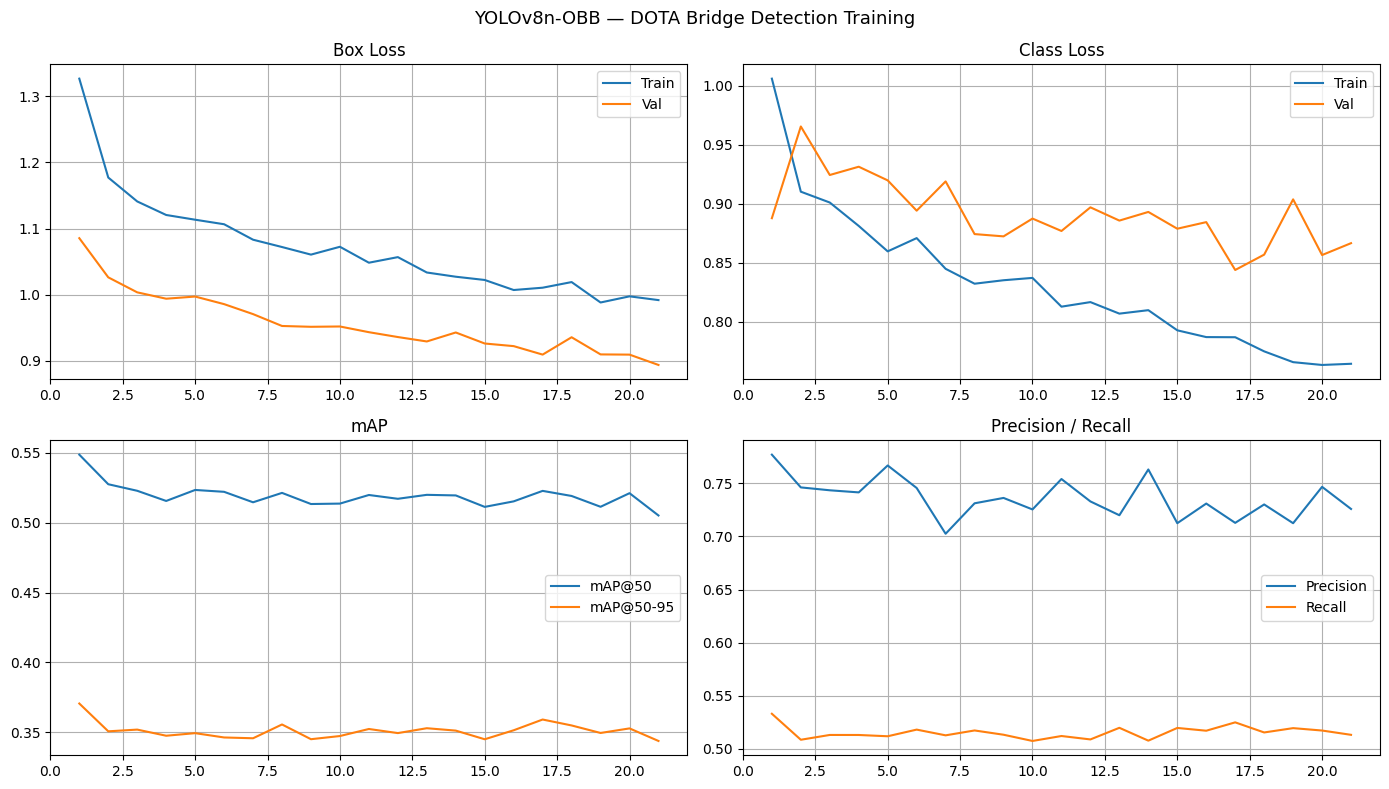

Saved: training_curves.png


In [17]:
# Cell 11: Plot loss and mAP curves for report
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

csv_path = Path("/kaggle/working/runs/bridge_obb_v2/results.csv")
df = pd.read_csv(csv_path)
df.columns = df.columns.str.strip()

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle("YOLOv8n-OBB — DOTA Bridge Detection Training", fontsize=13)

axes[0,0].plot(df["epoch"], df["train/box_loss"], label="Train")
axes[0,0].plot(df["epoch"], df["val/box_loss"],   label="Val")
axes[0,0].set_title("Box Loss"); axes[0,0].legend(); axes[0,0].grid(True)

axes[0,1].plot(df["epoch"], df["train/cls_loss"], label="Train")
axes[0,1].plot(df["epoch"], df["val/cls_loss"],   label="Val")
axes[0,1].set_title("Class Loss"); axes[0,1].legend(); axes[0,1].grid(True)

axes[1,0].plot(df["epoch"], df["metrics/mAP50(B)"],    label="mAP@50")
axes[1,0].plot(df["epoch"], df["metrics/mAP50-95(B)"], label="mAP@50-95")
axes[1,0].set_title("mAP"); axes[1,0].legend(); axes[1,0].grid(True)

axes[1,1].plot(df["epoch"], df["metrics/precision(B)"], label="Precision")
axes[1,1].plot(df["epoch"], df["metrics/recall(B)"],    label="Recall")
axes[1,1].set_title("Precision / Recall"); axes[1,1].legend(); axes[1,1].grid(True)

plt.tight_layout()
plt.savefig("/kaggle/working/training_curves.png", dpi=150)
plt.show()
print("Saved: training_curves.png")

In [19]:
# Cell 8: Train YOLOv8n-OBB on DOTA bridge data
from ultralytics import YOLO
from pathlib import Path

WORK_DIR  = Path("/kaggle/working")
yaml_path = WORK_DIR / "dota_bridge.yaml"

model = YOLO("yolov8n-obb.pt")   # nano = fastest on Kaggle T4

results = model.train(
    data      = str(yaml_path),
    epochs    = 50,
    imgsz     = 1024,          # DOTAv1 tiles are 1024x1024
    batch     = 8,             # safe for Kaggle T4 16GB at 1024px
    device    = 0,
    project   = str(WORK_DIR / "runs"),
    name      = "bridge_obb",
    patience  = 10,            # early stopping
    workers   = 2,

    # Augmentation — key for aerial bridge detection
    degrees   = 180.0,         # full rotation (bridges face all directions)
    flipud    = 0.5,
    fliplr    = 0.5,
    mosaic    = 1.0,
    scale     = 0.5,
    translate = 0.1,
    hsv_h     = 0.015,
    hsv_s     = 0.7,
    hsv_v     = 0.4,

    verbose   = True,
    exist_ok  = True
)

print("\n✅ Training complete!")
print("Best weights:", WORK_DIR / "runs/bridge_obb/weights/best.pt")

Ultralytics 8.4.37 🚀 Python-3.12.12 torch-2.11.0+cu130 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/dota_bridge.yaml, degrees=180.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.5, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1024, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-obb.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=bridge_obb, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, pat

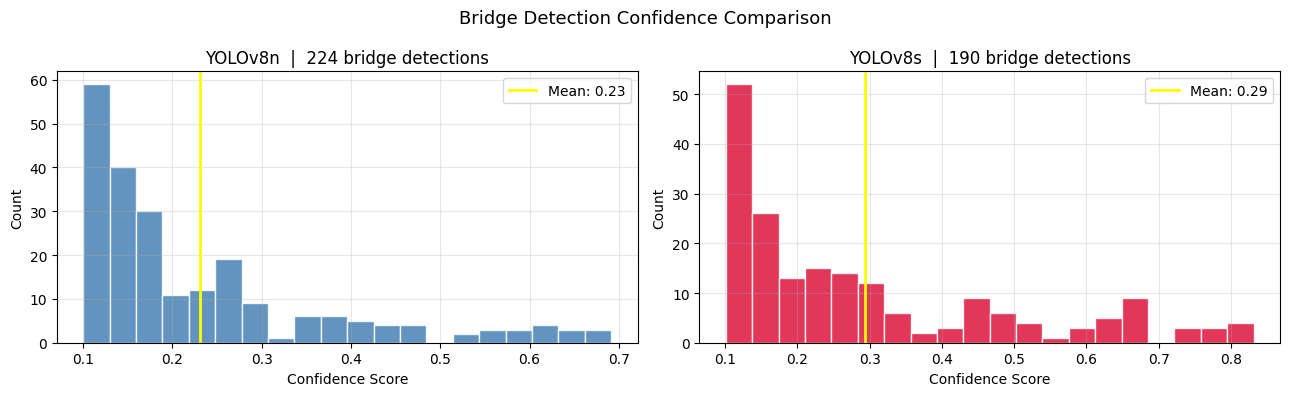

YOLOv8n: 224 detections | mean conf: 0.231 | high conf (>0.5): 18
YOLOv8s: 190 detections | mean conf: 0.293 | high conf (>0.5): 33


In [20]:
# Cell 12: Deep dive into bridge-specific performance
from ultralytics import YOLO
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

WORK_DIR     = Path("/kaggle/working")
DATASET_DIR  = WORK_DIR / "datasets/DOTAv1"
best_v1      = WORK_DIR / "runs/bridge_obb/weights/best.pt"
best_v2      = WORK_DIR / "runs/bridge_obb_v2/weights/best.pt"

# Compare confidence score distributions on bridge detections
models = {"YOLOv8n": best_v1, "YOLOv8s": best_v2}
bridge_confs = {name: [] for name in models}

val_imgs = list((DATASET_DIR / "images/val").glob("*.*"))[:100]

for model_name, weights in models.items():
    m = YOLO(str(weights))
    for img in val_imgs:
        res = m.predict(source=str(img), conf=0.1, verbose=False, device=0)[0]
        if res.obb is not None:
            for obb in res.obb:
                if int(obb.cls.item()) == 8:  # bridge
                    bridge_confs[model_name].append(obb.conf.item())

# Plot
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle("Bridge Detection Confidence Comparison", fontsize=13)

for ax, (name, confs) in zip(axes, bridge_confs.items()):
    if confs:
        ax.hist(confs, bins=20, color="crimson" if "s" in name else "steelblue",
                edgecolor="white", alpha=0.85)
        ax.axvline(np.mean(confs), color="yellow", linewidth=2,
                   label=f"Mean: {np.mean(confs):.2f}")
        ax.set_title(f"{name}  |  {len(confs)} bridge detections")
        ax.set_xlabel("Confidence Score")
        ax.set_ylabel("Count")
        ax.legend()
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(str(WORK_DIR / "bridge_confidence_comparison.png"), dpi=150)
plt.show()

for name, confs in bridge_confs.items():
    if confs:
        print(f"{name}: {len(confs)} detections | "
              f"mean conf: {np.mean(confs):.3f} | "
              f"high conf (>0.5): {sum(c>0.5 for c in confs)}")

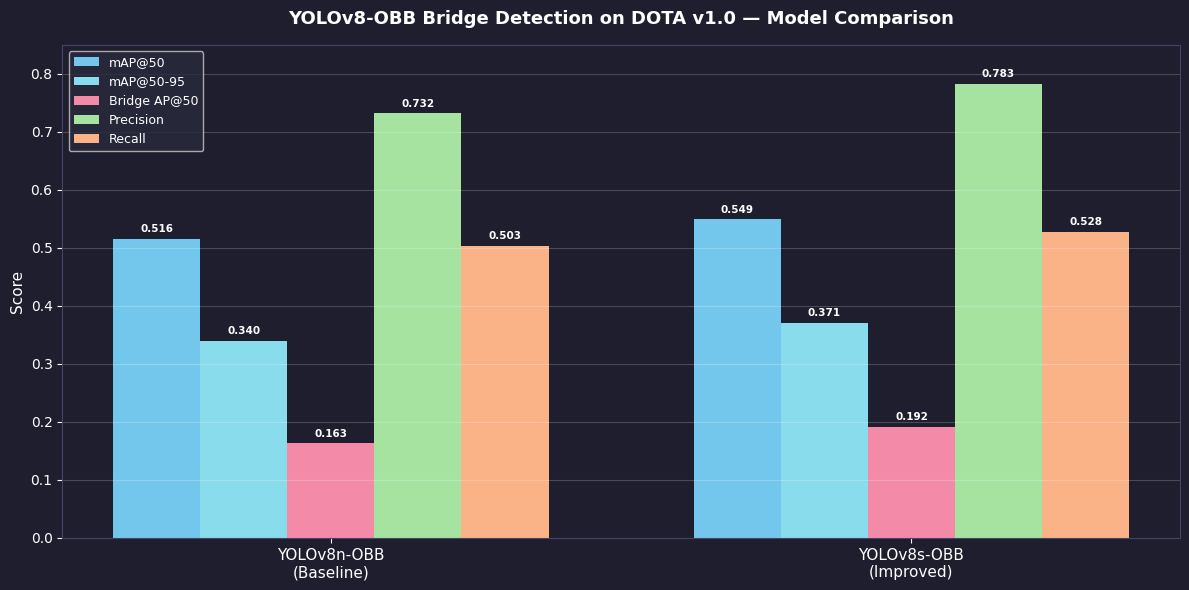

Saved: model_comparison.png


In [21]:
# Cell 13: Clean summary table — paste this directly into your report
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from pathlib import Path

WORK_DIR = Path("/kaggle/working")

# Data from your two runs
models    = ["YOLOv8n-OBB\n(Baseline)", "YOLOv8s-OBB\n(Improved)"]
map50     = [0.516,  0.549]
map5095   = [0.340,  0.371]
bridge_ap = [0.163,  0.192]
precision = [0.732,  0.783]
recall    = [0.503,  0.528]

x     = np.arange(len(models))
width = 0.15

fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor("#1e1e2e")
ax.set_facecolor("#1e1e2e")

bars1 = ax.bar(x - 2*width, map50,     width, label="mAP@50",        color="#74c7ec")
bars2 = ax.bar(x - 1*width, map5095,   width, label="mAP@50-95",     color="#89dceb")
bars3 = ax.bar(x,            bridge_ap, width, label="Bridge AP@50",  color="#f38ba8")
bars4 = ax.bar(x + 1*width, precision, width, label="Precision",      color="#a6e3a1")
bars5 = ax.bar(x + 2*width, recall,    width, label="Recall",         color="#fab387")

# Value labels on bars
for bars in [bars1, bars2, bars3, bars4, bars5]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.008,
                f"{bar.get_height():.3f}", ha="center", va="bottom",
                fontsize=7.5, color="white", fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(models, color="white", fontsize=11)
ax.set_ylabel("Score", color="white", fontsize=11)
ax.set_title("YOLOv8-OBB Bridge Detection on DOTA v1.0 — Model Comparison",
             color="white", fontsize=13, fontweight="bold", pad=15)
ax.set_ylim(0, 0.85)
ax.tick_params(colors="white")
ax.spines[:].set_color("#444466")
ax.legend(facecolor="#2a2a3e", labelcolor="white", fontsize=9)
ax.grid(axis="y", alpha=0.2, color="white")

plt.tight_layout()
plt.savefig(str(WORK_DIR / "model_comparison.png"), dpi=150, facecolor=fig.get_facecolor())
plt.show()
print("Saved: model_comparison.png")